In [1]:
# ============================================================
# PHASE 2.2 — GENOMIC THRESHOLD TUNING + CURVES + ERROR ANALYSIS
# ============================================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import joblib

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 150)

In [2]:
# ============================================================
# PATHS
# ============================================================
import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

PHASE1_ANALYSIS_DIR = PROJECT_DIR / "model" / "phase1_final_protein_analysis"
PHASE2_DIR = PROJECT_DIR / "model" / "phase2_genomic_regulatory_baseline"

SPLIT_DIR = PHASE2_DIR / "splits"
FEATURE_DIR = PHASE2_DIR / "features"
RESULT_DIR = PHASE2_DIR / "results"
MODEL_DIR = PHASE2_DIR / "models"

PHASE2_ANALYSIS_DIR = PROJECT_DIR / "model" / "phase2_2_genomic_analysis"
PHASE2_RESULT_DIR = PHASE2_ANALYSIS_DIR / "results"
PHASE2_FIGURE_DIR = PHASE2_ANALYSIS_DIR / "figures"
PHASE2_REPORT_DIR = PHASE2_ANALYSIS_DIR / "reports"

for folder in [PHASE2_ANALYSIS_DIR, PHASE2_RESULT_DIR, PHASE2_FIGURE_DIR, PHASE2_REPORT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 2.2 output:", PHASE2_ANALYSIS_DIR)

Mounted at /content/drive
Phase 2.2 output: /content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis


In [3]:
# ============================================================
# LOAD SPLITS
# ============================================================

train_df = pd.read_csv(SPLIT_DIR / "train_genomic_regulatory_v1.csv")
val_df = pd.read_csv(SPLIT_DIR / "val_genomic_regulatory_v1.csv")
test_df = pd.read_csv(SPLIT_DIR / "test_genomic_regulatory_v1.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["label"].value_counts().sort_index())

print("\nValidation labels:")
print(val_df["label"].value_counts().sort_index())

print("\nTest labels:")
print(test_df["label"].value_counts().sort_index())

Train: (1264, 20)
Validation: (271, 20)
Test: (271, 20)

Train labels:
label
0    632
1    632
Name: count, dtype: int64

Validation labels:
label
0    135
1    136
Name: count, dtype: int64

Test labels:
label
0    136
1    135
Name: count, dtype: int64


In [4]:
# ============================================================
# LOAD MAIN FEATURE SET: K3 + K4 + BASIC
# ============================================================

X_train = pd.read_csv(FEATURE_DIR / "X_train_k3_k4_plus_basic_v1.csv")
X_val = pd.read_csv(FEATURE_DIR / "X_val_k3_k4_plus_basic_v1.csv")
X_test = pd.read_csv(FEATURE_DIR / "X_test_k3_k4_plus_basic_v1.csv")

y_train = train_df["label"].astype(int).values
y_val = val_df["label"].astype(int).values
y_test = test_df["label"].astype(int).values

MAIN_FEATURE_SET_NAME = "K3 + K4 + Basic"

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

assert X_train.shape[0] == len(y_train)
assert X_val.shape[0] == len(y_val)
assert X_test.shape[0] == len(y_test)

display(X_train.head())

X_train: (1264, 356)
X_val: (271, 356)
X_test: (271, 356)


,seq_length,A_count,C_count,G_count,T_count,A_frac,C_frac,G_frac,T_frac,GC_count,AT_count,GC_content,AT_content,CpG_count,CpG_density,CpG_observed_expected,GC_skew,AT_skew,purine_frac_AG,pyrimidine_frac_CT,GC_content_bin_01,GC_content_bin_02,GC_content_bin_03,GC_content_bin_04,GC_content_bin_05,GC_content_bin_06,GC_content_bin_07,GC_content_bin_08,GC_content_bin_09,GC_content_bin_10,GC_content_upstream_2kb,GC_content_downstream_500bp,GC_content_tss_near_500bp,CpG_count_upstream_2kb,CpG_count_downstream_500bp,CpG_count_tss_near_500bp,k3_AAA,k3_AAC,k3_AAG,k3_AAT,k3_ACA,k3_ACC,k3_ACG,k3_ACT,k3_AGA,k3_AGC,k3_AGG,k3_AGT,k3_ATA,k3_ATC,k3_ATG,k3_ATT,k3_CAA,k3_CAC,k3_CAG,k3_CAT,k3_CCA,k3_CCC,k3_CCG,k3_CCT,k3_CGA,k3_CGC,k3_CGG,k3_CGT,k3_CTA,k3_CTC,k3_CTG,k3_CTT,k3_GAA,k3_GAC,k3_GAG,k3_GAT,k3_GCA,k3_GCC,k3_GCG,k3_GCT,k3_GGA,k3_GGC,k3_GGG,k3_GGT,k3_GTA,k3_GTC,k3_GTG,k3_GTT,k3_TAA,k3_TAC,k3_TAG,k3_TAT,k3_TCA,k3_TCC,k3_TCG,k3_TCT,k3_TGA,k3_TGC,k3_TGG,k3_TGT,k3_TTA,k3_TTC,k3_TTG,k3_TTT,...,k4_GCTA,k4_GCTC,k4_GCTG,k4_GCTT,k4_GGAA,k4_GGAC,k4_GGAG,k4_GGAT,k4_GGCA,k4_GGCC,k4_GGCG,k4_GGCT,k4_GGGA,k4_GGGC,k4_GGGG,k4_GGGT,k4_GGTA,k4_GGTC,k4_GGTG,k4_GGTT,k4_GTAA,k4_GTAC,k4_GTAG,k4_GTAT,k4_GTCA,k4_GTCC,k4_GTCG,k4_GTCT,k4_GTGA,k4_GTGC,k4_GTGG,k4_GTGT,k4_GTTA,k4_GTTC,k4_GTTG,k4_GTTT,k4_TAAA,k4_TAAC,k4_TAAG,k4_TAAT,k4_TACA,k4_TACC,k4_TACG,k4_TACT,k4_TAGA,k4_TAGC,k4_TAGG,k4_TAGT,k4_TATA,k4_TATC,k4_TATG,k4_TATT,k4_TCAA,k4_TCAC,k4_TCAG,k4_TCAT,k4_TCCA,k4_TCCC,k4_TCCG,k4_TCCT,k4_TCGA,k4_TCGC,k4_TCGG,k4_TCGT,k4_TCTA,k4_TCTC,k4_TCTG,k4_TCTT,k4_TGAA,k4_TGAC,k4_TGAG,k4_TGAT,k4_TGCA,k4_TGCC,k4_TGCG,k4_TGCT,k4_TGGA,k4_TGGC,k4_TGGG,k4_TGGT,k4_TGTA,k4_TGTC,k4_TGTG,k4_TGTT,k4_TTAA,k4_TTAC,k4_TTAG,k4_TTAT,k4_TTCA,k4_TTCC,k4_TTCG,k4_TTCT,k4_TTGA,k4_TTGC,k4_TTGG,k4_TTGT,k4_TTTA,k4_TTTC,k4_TTTG,k4_TTTT
0,2500,753,531,492,724,0.3012,0.2124,0.1968,0.2896,1023,1477,0.4092,0.5908,42,0.0168,0.401911,-0.038123,0.019634,0.4980,0.5020,0.300,0.280,0.312,0.300,0.356,0.408,0.424,0.632,0.464,0.616,0.3765,0.540,0.548,25,17,26,0.041633,0.014812,0.020416,0.028022,0.017214,0.011209,0.004003,0.013611,0.017614,0.015212,0.015212,0.014812,0.025220,0.015212,0.018415,0.028423,0.020416,0.010809,0.018415,0.019616,0.019215,0.013211,0.003603,0.020416,0.004003,0.005204,0.003603,0.004003,0.012810,0.020416,0.018815,0.017614,0.020817,0.007206,0.015212,0.009608,0.015612,0.015212,0.003603,0.012410,0.016413,0.008807,0.017614,0.009207,0.014812,0.006805,0.012010,0.011609,0.022018,0.012810,0.008807,0.030024,0.017614,0.016813,0.005604,0.023219,0.014812,0.017614,0.015612,0.017214,0.020817,0.020817,0.016013,0.030024,...,0.002403,0.002803,0.005206,0.002002,0.006408,0.001602,0.005206,0.003204,0.003204,0.001602,0.001201,0.002803,0.004405,0.002403,0.006408,0.004405,0.002803,0.002403,0.002803,0.001201,0.004806,0.002403,0.002002,0.005607,0.004005,0.001201,0.000400,0.001201,0.002403,0.004005,0.003604,0.002002,0.002002,0.002403,0.002403,0.004806,0.009211,0.001201,0.004005,0.007609,0.005607,0.002403,0.001201,0.003604,0.002002,0.004005,0.001201,0.001602,0.009612,0.004806,0.006007,0.009612,0.006408,0.002803,0.004005,0.004005,0.006808,0.004806,0.000400,0.004806,0.002002,0.002403,0.000400,0.000801,0.005206,0.006007,0.004806,0.007209,0.006408,0.003204,0.002403,0.002803,0.006408,0.007209,0.000400,0.003604,0.006408,0.002403,0.004005,0.002803,0.006408,0.001602,0.004806,0.004405,0.006808,0.003204,0.002002,0.008811,0.005607,0.008410,0.000801,0.006007,0.004005,0.003604,0.004005,0.004405,0.007209,0.004806,0.006808,0.011213
1,2500,805,391,484,820,0.3220,0.1564,0.1936,0.3280,875,1625,0.3500,0.6500,13,0.0052,0.171736,0.106286,-0.009231,0.5156,0.4844,0.360,0.348,0.276,0.268,0.388,0.384,0.328,0.408,0.388,0.352,0.3450,0.370,0.398,7,6,4,0.043235,0.015212,0.020416,0.036429,0.019215,0.005604,0.002002,0.013211,0.024019,0.011609,0.018815,0.017214,0.025620,0.014412,0.017614,0.037630,0.019215,0.007606,0.018014,0.015212,0.011209,0.005204,0.001201,0.014812,0.001601,0.000801,0.002002,0.000801,0.014011,0.008407,0.016413,0.019215,0.026021,0.0068

In [5]:
# ============================================================
# LOAD TRAINED GENOMIC MODELS
# ============================================================

model_paths = {
    "Logistic Regression": MODEL_DIR / "phase2_1_genomic_logistic_regression_best_estimator_v1.pkl",
    "SVM RBF": MODEL_DIR / "phase2_1_genomic_svm_rbf_best_estimator_v1.pkl",
    "Random Forest": MODEL_DIR / "phase2_1_genomic_random_forest_best_estimator_v1.pkl",
    "LightGBM": MODEL_DIR / "phase2_1_genomic_lightgbm_best_estimator_v1.pkl",
    "Soft Voting": MODEL_DIR / "phase2_1_genomic_soft_voting_best_estimator_v1.pkl",
    "Stacking": MODEL_DIR / "phase2_1_genomic_stacking_best_estimator_v1.pkl",
}

genomic_models = {}

for model_name, path in model_paths.items():
    if path.exists():
        genomic_models[model_name] = joblib.load(path)
        print("Loaded:", model_name, "|", path)
    else:
        print("Missing, skipped:", model_name, "|", path)

print("\nLoaded models:")
print(list(genomic_models.keys()))

Loaded: Logistic Regression | /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/models/phase2_1_genomic_logistic_regression_best_estimator_v1.pkl
Loaded: SVM RBF | /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/models/phase2_1_genomic_svm_rbf_best_estimator_v1.pkl
Loaded: Random Forest | /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/models/phase2_1_genomic_random_forest_best_estimator_v1.pkl
Loaded: LightGBM | /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/models/phase2_1_genomic_lightgbm_best_estimator_v1.pkl
Loaded: Soft Voting | /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/models/phase2_1_genomic_soft_voting_best_estimator_v1.pkl
Loaded: Stacking | /content/drive/MyDrive/Project_Protein/model/phase2_genomic_regulatory_baseline/models/phase2_1_genomic_stacking_best_estimator_v1.pkl

Loaded models:
['Logistic Regression', 

In [6]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def get_positive_class_score(model, X):
    """
    Return score/probability for positive class 1.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]

    if hasattr(model, "decision_function"):
        return model.decision_function(X)

    return model.predict(X)


def evaluate_with_threshold(y_true, y_score, threshold=0.5):
    """
    Evaluate binary metrics using custom threshold.
    """
    y_pred = (y_score >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    balanced_accuracy = (recall_score(y_true, y_pred, zero_division=0) + specificity) / 2
    youden_j = recall_score(y_true, y_pred, zero_division=0) + specificity - 1

    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall_sensitivity": recall_score(y_true, y_pred, zero_division=0),
        "specificity": specificity,
        "balanced_accuracy": balanced_accuracy,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "youden_j": youden_j,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


def tune_threshold_on_validation(y_val, y_val_score, metric="mcc", thresholds=None):
    """
    Tune threshold using validation set only.
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.951, 0.001)

    rows = []

    for th in thresholds:
        metrics = evaluate_with_threshold(
            y_true=y_val,
            y_score=y_val_score,
            threshold=float(th)
        )
        rows.append(metrics)

    threshold_df = pd.DataFrame(rows)

    if metric not in threshold_df.columns:
        raise ValueError(f"Unknown metric: {metric}")

    best_row = threshold_df.sort_values(
        by=[metric, "roc_auc", "pr_auc"],
        ascending=False
    ).iloc[0]

    return best_row, threshold_df


def build_prediction_table(meta_df, y_true, y_score, threshold, model_name, feature_set):
    """
    Build prediction table for error analysis.
    """
    y_pred = (y_score >= threshold).astype(int)

    pred_df = meta_df.copy()
    pred_df["true_label"] = y_true
    pred_df["pred_score_t2d_associated"] = y_score
    pred_df["pred_label"] = y_pred
    pred_df["threshold"] = threshold
    pred_df["model"] = model_name
    pred_df["feature_set"] = feature_set

    def classify_error(row):
        if row["true_label"] == 1 and row["pred_label"] == 1:
            return "TP"
        if row["true_label"] == 0 and row["pred_label"] == 0:
            return "TN"
        if row["true_label"] == 0 and row["pred_label"] == 1:
            return "FP"
        if row["true_label"] == 1 and row["pred_label"] == 0:
            return "FN"
        return "UNKNOWN"

    pred_df["error_type"] = pred_df.apply(classify_error, axis=1)

    return pred_df

In [7]:
# ============================================================
# GET VALIDATION AND TEST SCORES
# ============================================================

model_score_records = []

val_scores = {}
test_scores = {}

for model_name, model in genomic_models.items():
    val_score = get_positive_class_score(model, X_val)
    test_score = get_positive_class_score(model, X_test)

    val_scores[model_name] = val_score
    test_scores[model_name] = test_score

    default_val_metrics = evaluate_with_threshold(
        y_true=y_val,
        y_score=val_score,
        threshold=0.5
    )

    default_test_metrics = evaluate_with_threshold(
        y_true=y_test,
        y_score=test_score,
        threshold=0.5
    )

    model_score_records.append({
        "model": model_name,
        "feature_set": MAIN_FEATURE_SET_NAME,
        "threshold": 0.5,

        "val_roc_auc": default_val_metrics["roc_auc"],
        "val_pr_auc": default_val_metrics["pr_auc"],
        "val_f1": default_val_metrics["f1"],
        "val_mcc": default_val_metrics["mcc"],

        "test_roc_auc": default_test_metrics["roc_auc"],
        "test_pr_auc": default_test_metrics["pr_auc"],
        "test_f1": default_test_metrics["f1"],
        "test_mcc": default_test_metrics["mcc"],
        "test_accuracy": default_test_metrics["accuracy"],
        "test_precision": default_test_metrics["precision"],
        "test_recall_sensitivity": default_test_metrics["recall_sensitivity"],
        "test_specificity": default_test_metrics["specificity"],
        "test_tn": default_test_metrics["tn"],
        "test_fp": default_test_metrics["fp"],
        "test_fn": default_test_metrics["fn"],
        "test_tp": default_test_metrics["tp"],
    })

default_genomic_threshold_df = pd.DataFrame(model_score_records).sort_values(
    by=["test_roc_auc", "test_mcc", "test_f1"],
    ascending=False
)

display(default_genomic_threshold_df)

default_genomic_threshold_df.to_csv(
    PHASE2_RESULT_DIR / "phase2_2_default_threshold_all_genomic_models.csv",
    index=False
)

,model,feature_set,threshold,val_roc_auc,val_pr_auc,val_f1,val_mcc,test_roc_auc,test_pr_auc,test_f1,test_mcc,test_accuracy,test_precision,test_recall_sensitivity,test_specificity,test_tn,test_fp,test_fn,test_tp
1,SVM RBF,K3 + K4 + Basic,0.5,0.649918,0.669187,0.607143,0.188333,0.676471,0.650405,0.661972,0.293342,0.645756,0.630872,0.696296,0.595588,81,55,41,94
4,Soft Voting,K3 + K4 + Basic,0.5,0.658061,0.693627,0.617100,0.239963,0.672004,0.648989,0.640288,0.262601,0.630996,0.622378,0.659259,0.602941,82,54,46,89
5,Stacking,K3 + K4 + Basic,0.5,0.659205,0.691735,0.617647,0.232462,0.671514,0.650205,0.640288,0.262601,0.630996,0.622378,0.659259,0.602941,82,54,46,89
0,Logistic Regression,K3 + K4 + Basic,0.5,0.653540,0.673381,0.617100,0.239963,0.659259,0.647477,0.625899,0.233035,0.616236,0.608392,0.644444,0.588235,80,56,48,87
2,Random Forest,K3 + K4 + Basic,0.5,0.670752,0.704442,0.607004,0.256482,0.649619,0.632732,0.640569,0.255669,0.627306,0.616438,0.666667,0.588235,80,56,45,90
3,LightGBM,K3 + K4 + Basic,0.5,0.632898,0.674220,0.595588,0.188181,0.649401,0.623016,0.612676,0.189504,0.594096,0.583893,0.644444,0.544118,74,62,48,87


In [8]:
# ============================================================
# THRESHOLD TUNING FOR KEY GENOMIC MODELS
# ============================================================

key_models_for_threshold = [
    "Random Forest",
    "SVM RBF",
    "Logistic Regression"
]

threshold_tuning_records = []
threshold_curve_dfs = {}

for model_name in key_models_for_threshold:
    if model_name not in genomic_models:
        print("Skipped missing model:", model_name)
        continue

    print("=" * 100)
    print("Threshold tuning:", model_name)

    for tune_metric in ["mcc", "f1", "balanced_accuracy", "youden_j"]:
        best_val_row, threshold_curve_df = tune_threshold_on_validation(
            y_val=y_val,
            y_val_score=val_scores[model_name],
            metric=tune_metric
        )

        best_threshold = float(best_val_row["threshold"])

        val_metrics = evaluate_with_threshold(
            y_true=y_val,
            y_score=val_scores[model_name],
            threshold=best_threshold
        )

        test_metrics = evaluate_with_threshold(
            y_true=y_test,
            y_score=test_scores[model_name],
            threshold=best_threshold
        )

        row = {
            "model": model_name,
            "feature_set": MAIN_FEATURE_SET_NAME,
            "tuned_for": tune_metric,
            "best_threshold": best_threshold,

            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall_sensitivity": val_metrics["recall_sensitivity"],
            "val_specificity": val_metrics["specificity"],
            "val_balanced_accuracy": val_metrics["balanced_accuracy"],
            "val_f1": val_metrics["f1"],
            "val_mcc": val_metrics["mcc"],
            "val_roc_auc": val_metrics["roc_auc"],
            "val_pr_auc": val_metrics["pr_auc"],
            "val_tn": val_metrics["tn"],
            "val_fp": val_metrics["fp"],
            "val_fn": val_metrics["fn"],
            "val_tp": val_metrics["tp"],

            "test_accuracy": test_metrics["accuracy"],
            "test_precision": test_metrics["precision"],
            "test_recall_sensitivity": test_metrics["recall_sensitivity"],
            "test_specificity": test_metrics["specificity"],
            "test_balanced_accuracy": test_metrics["balanced_accuracy"],
            "test_f1": test_metrics["f1"],
            "test_mcc": test_metrics["mcc"],
            "test_roc_auc": test_metrics["roc_auc"],
            "test_pr_auc": test_metrics["pr_auc"],
            "test_tn": test_metrics["tn"],
            "test_fp": test_metrics["fp"],
            "test_fn": test_metrics["fn"],
            "test_tp": test_metrics["tp"],
        }

        threshold_tuning_records.append(row)

        threshold_curve_dfs[(model_name, tune_metric)] = threshold_curve_df

        print(f"Tuned for: {tune_metric}")
        print("Best threshold:", best_threshold)
        print("Val F1/MCC:", val_metrics["f1"], val_metrics["mcc"])
        print("Test F1/MCC:", test_metrics["f1"], test_metrics["mcc"])
        print()

genomic_threshold_tuning_df = pd.DataFrame(threshold_tuning_records)

display(
    genomic_threshold_tuning_df.sort_values(
        by=["test_mcc", "test_f1", "test_roc_auc"],
        ascending=False
    )
)

genomic_threshold_tuning_df.to_csv(
    PHASE2_RESULT_DIR / "phase2_2_genomic_threshold_tuning_results.csv",
    index=False
)

Threshold tuning: Random Forest
Tuned for: mcc
Best threshold: 0.6000000000000005
Val F1/MCC: 0.47619047619047616 0.3424024378976467
Test F1/MCC: 0.40625 0.19204637361434412

Tuned for: f1
Best threshold: 0.22400000000000014
Val F1/MCC: 0.6699507389162561 0.06108304630544683
Test F1/MCC: 0.6650246305418719 0.0

Tuned for: balanced_accuracy
Best threshold: 0.5180000000000005
Val F1/MCC: 0.6 0.3006085048303226
Test F1/MCC: 0.6287878787878788 0.27689641361474043

Tuned for: youden_j
Best threshold: 0.5180000000000005
Val F1/MCC: 0.6 0.3006085048303226
Test F1/MCC: 0.6287878787878788 0.27689641361474043

Threshold tuning: SVM RBF
Tuned for: mcc
Best threshold: 0.5610000000000005
Val F1/MCC: 0.5504587155963303 0.30281453817732307
Test F1/MCC: 0.5652173913043478 0.27338900125466986

Tuned for: f1
Best threshold: 0.23400000000000015
Val F1/MCC: 0.671604938271605 0.08654488950215276
Test F1/MCC: 0.6650246305418719 0.0

Tuned for: balanced_accuracy
Best threshold: 0.5610000000000005
Val F1/MCC:

,model,feature_set,tuned_for,best_threshold,val_accuracy,val_precision,val_recall_sensitivity,val_specificity,val_balanced_accuracy,val_f1,val_mcc,val_roc_auc,val_pr_auc,val_tn,val_fp,val_fn,val_tp,test_accuracy,test_precision,test_recall_sensitivity,test_specificity,test_balanced_accuracy,test_f1,test_mcc,test_roc_auc,test_pr_auc,test_tn,test_fp,test_fn,test_tp
2,Random Forest,K3 + K4 + Basic,balanced_accuracy,0.518,0.645756,0.692308,0.529412,0.762963,0.646187,0.600000,0.300609,0.670752,0.704442,103,32,64,72,0.638376,0.643411,0.614815,0.661765,0.638290,0.628788,0.276896,0.649619,0.632732,90,46,52,83
3,Random Forest,K3 + K4 + Basic,youden_j,0.518,0.645756,0.692308,0.529412,0.762963,0.646187,0.600000,0.300609,0.670752,0.704442,103,32,64,72,0.638376,0.643411,0.614815,0.661765,0.638290,0.628788,0.276896,0.649619,0.632732,90,46,52,83
4,SVM RBF,K3 + K4 + Basic,mcc,0.561,0.638376,0.731707,0.441176,0.837037,0.639107,0.550459,0.302815,0.649918,0.669187,113,22,76,60,0.630996,0.684211,0.481481,0.779412,0.630447,0.565217,0.273389,0.676471,0.650405,106,30,70,65
6,SVM RBF,K3 + K4 + Basic,balanced_accuracy,0.561,0.638376,0.731707,0.441176,0.837037,0.639107,0.550459,0.302815,0.649918,0.669187,113,22,76,60,0.630996,0.684211,0.481481,0.779412,0.630447,0.565217,0.273389,0.676471,0.650405,106,30,70,65
7,SVM RBF,K3 + K4 + Basic,youden_j,0.561,0.638376,0.731707,0.441176,0.837037,0.639107,0.550459,0.302815,0.649918,0.669187,113,22,76,60,0.630996,0.684211,0.481481,0.779412,0.630447,0.565217,0.273389,0.676471,0.650405,106,30,70,65
8,Logistic Regression,K3 + K4 + Basic,mcc,0.567,0.634686,0.784615,0.375000,0.896296,0.635648,0.507463,0.317680,0.653540,0.673381,121,14,85,51,0.623616,0.714286,0.407407,0.838235,0.622821,0.518868,0.272329,0.659259,0.647477,114,22,80,55
10,Logistic Regression,K3 + K4 + Basic,balanced_accuracy,0.538,0.642066,0.714286,0.477941,0.807407,0.642674,0.572687,0.302103,0.653540,0.673381,109,26,71,65,0.630996,0.666667,0.518519,0.742647,0.630583,0.583333,0.268042,0.659259,0.647477,101,35,65,70
11,Logistic Regression,K3 + K4 + Basic,youden_j,0.538,0.642066,0.714286,0.477941,0.807407,0.642674,0.572687,0.302103,0.653540,0.673381,109,26,71,65,0.630996,0.666667,0.518519,0.742647,0.630583,0.583333,0.268042,0.659259,0.647477,101,35,65,70
0,Random Forest,K3 + K4 + Basic,mcc,0.600,0.634686,0.849057,0.330882,0.940741,0.635812,0.476190,0.342402,0.670752,0.704442,127,8,91,45,0.579336,0.684211,0.288889,0.867647,0.578268,0.406250,0.192046,0.649619,0.632732,118,18,96,39
9,Logistic Regression,K3 + K4 + Basic,f1,0.277,0.516605,0.509506,0.985294,0.044444,0.514869,0.671679,0.087848,0.653540,0.673381,6,129,2,134,0.509225,0.503731,1.000000,0.022059,0.511029,0.669975,0.105412,0.659259,0.647477,3,133,0,135


In [9]:
# ============================================================
# SELECT RECOMMENDED THRESHOLDS
# ============================================================

# Main recommendation:
# - Random Forest tuned for MCC: conservative final selected model
# - SVM tuned for MCC/F1: diagnostic best model
# - SVM threshold may be used for practical binary analysis, but not for official final model selection

recommended_threshold_rows = genomic_threshold_tuning_df[
    genomic_threshold_tuning_df["tuned_for"].isin(["mcc", "f1"])
].copy()

recommended_threshold_rows = recommended_threshold_rows.sort_values(
    by=["test_mcc", "test_f1", "test_roc_auc"],
    ascending=False
)

display(recommended_threshold_rows)

recommended_threshold_rows.to_csv(
    PHASE2_RESULT_DIR / "phase2_2_recommended_threshold_candidates.csv",
    index=False
)

# Official final selected model by validation ROC-AUC from Phase 2.1
OFFICIAL_FINAL_MODEL_NAME = "Random Forest"

official_rf_mcc_row = genomic_threshold_tuning_df[
    (genomic_threshold_tuning_df["model"] == OFFICIAL_FINAL_MODEL_NAME) &
    (genomic_threshold_tuning_df["tuned_for"] == "mcc")
].iloc[0]

official_rf_threshold = float(official_rf_mcc_row["best_threshold"])

print("Official final model:", OFFICIAL_FINAL_MODEL_NAME)
print("Official recommended threshold tuned for MCC:", official_rf_threshold)
display(pd.DataFrame([official_rf_mcc_row]))

,model,feature_set,tuned_for,best_threshold,val_accuracy,val_precision,val_recall_sensitivity,val_specificity,val_balanced_accuracy,val_f1,val_mcc,val_roc_auc,val_pr_auc,val_tn,val_fp,val_fn,val_tp,test_accuracy,test_precision,test_recall_sensitivity,test_specificity,test_balanced_accuracy,test_f1,test_mcc,test_roc_auc,test_pr_auc,test_tn,test_fp,test_fn,test_tp
4,SVM RBF,K3 + K4 + Basic,mcc,0.561,0.638376,0.731707,0.441176,0.837037,0.639107,0.550459,0.302815,0.649918,0.669187,113,22,76,60,0.630996,0.684211,0.481481,0.779412,0.630447,0.565217,0.273389,0.676471,0.650405,106,30,70,65
8,Logistic Regression,K3 + K4 + Basic,mcc,0.567,0.634686,0.784615,0.375000,0.896296,0.635648,0.507463,0.317680,0.653540,0.673381,121,14,85,51,0.623616,0.714286,0.407407,0.838235,0.622821,0.518868,0.272329,0.659259,0.647477,114,22,80,55
0,Random Forest,K3 + K4 + Basic,mcc,0.600,0.634686,0.849057,0.330882,0.940741,0.635812,0.476190,0.342402,0.670752,0.704442,127,8,91,45,0.579336,0.684211,0.288889,0.867647,0.578268,0.406250,0.192046,0.649619,0.632732,118,18,96,39
9,Logistic Regression,K3 + K4 + Basic,f1,0.277,0.516605,0.509506,0.985294,0.044444,0.514869,0.671679,0.087848,0.653540,0.673381,6,129,2,134,0.509225,0.503731,1.000000,0.022059,0.511029,0.669975,0.105412,0.659259,0.647477,3,133,0,135
5,SVM RBF,K3 + K4 + Basic,f1,0.234,0.509225,0.505576,1.000000,0.014815,0.507407,0.671605,0.086545,0.649918,0.669187,2,133,0,136,0.498155,0.498155,1.000000,0.000000,0.500000,0.665025,0.000000,0.676471,0.650405,0,136,0,135
1,Random Forest,K3 + K4 + Basic,f1,0.224,0.505535,0.503704,1.000000,0.007407,0.503704,0.669951,0.061083,0.670752,0.704442,1,134,0,136,0.498155,0.498155,1.000000,0.000000,0.500000,0.665025,0.000000,0.649619,0.632732,0,136,0,135


Official final model: Random Forest
Official recommended threshold tuned for MCC: 0.6000000000000005


,model,feature_set,tuned_for,best_threshold,val_accuracy,val_precision,val_recall_sensitivity,val_specificity,val_balanced_accuracy,val_f1,val_mcc,val_roc_auc,val_pr_auc,val_tn,val_fp,val_fn,val_tp,test_accuracy,test_precision,test_recall_sensitivity,test_specificity,test_balanced_accuracy,test_f1,test_mcc,test_roc_auc,test_pr_auc,test_tn,test_fp,test_fn,test_tp
0,Random Forest,K3 + K4 + Basic,mcc,0.6,0.634686,0.849057,0.330882,0.940741,0.635812,0.47619,0.342402,0.670752,0.704442,127,8,91,45,0.579336,0.684211,0.288889,0.867647,0.578268,0.40625,0.192046,0.649619,0.632732,118,18,96,39


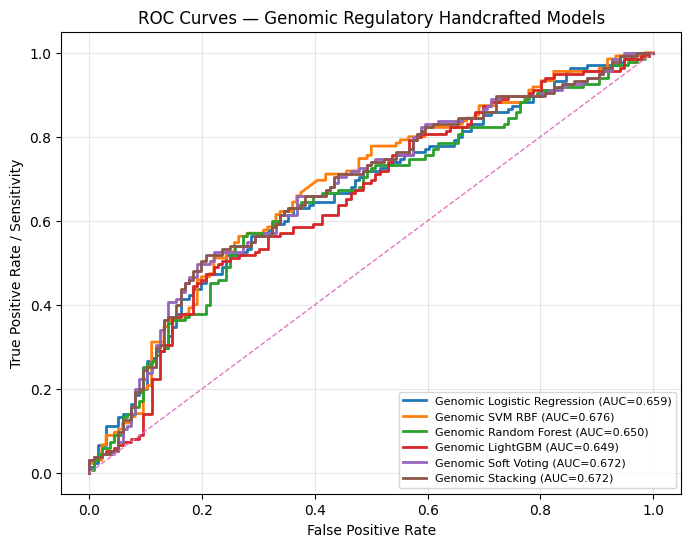

,branch,model,feature_set,roc_auc
1,Genomic regulatory,SVM RBF,K3 + K4 + Basic,0.676471
4,Genomic regulatory,Soft Voting,K3 + K4 + Basic,0.672004
5,Genomic regulatory,Stacking,K3 + K4 + Basic,0.671514
0,Genomic regulatory,Logistic Regression,K3 + K4 + Basic,0.659259
2,Genomic regulatory,Random Forest,K3 + K4 + Basic,0.649619
3,Genomic regulatory,LightGBM,K3 + K4 + Basic,0.649401


Saved: /content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/figures/phase2_2_roc_curves_genomic_models.png


In [20]:
# ============================================================
# ROC CURVES — GENOMIC MODELS
# ============================================================

plt.figure(figsize=(8, 6))

roc_rows = []

for model_name, score in test_scores.items():
    fpr, tpr, _ = roc_curve(y_test, score)
    roc_auc = roc_auc_score(y_test, score)

    plt.plot(fpr, tpr, linewidth=2, label=f"Genomic {model_name} (AUC={roc_auc:.3f})")

    roc_rows.append({
        "branch": "Genomic regulatory",
        "model": model_name,
        "feature_set": MAIN_FEATURE_SET_NAME,
        "roc_auc": roc_auc
    })

# Protein reference horizontal information is not a curve unless we load its predictions.
# Add diagonal line.
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.title("ROC Curves — Genomic Regulatory Handcrafted Models")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True, alpha=0.3)

roc_fig_path = PHASE2_FIGURE_DIR / "phase2_2_roc_curves_genomic_models.png"
plt.savefig(roc_fig_path, dpi=300, bbox_inches="tight")
plt.show()

genomic_roc_summary_df = pd.DataFrame(roc_rows).sort_values(
    by="roc_auc",
    ascending=False
)

display(genomic_roc_summary_df)

genomic_roc_summary_df.to_csv(
    PHASE2_RESULT_DIR / "phase2_2_genomic_roc_summary.csv",
    index=False
)

print("Saved:", roc_fig_path)

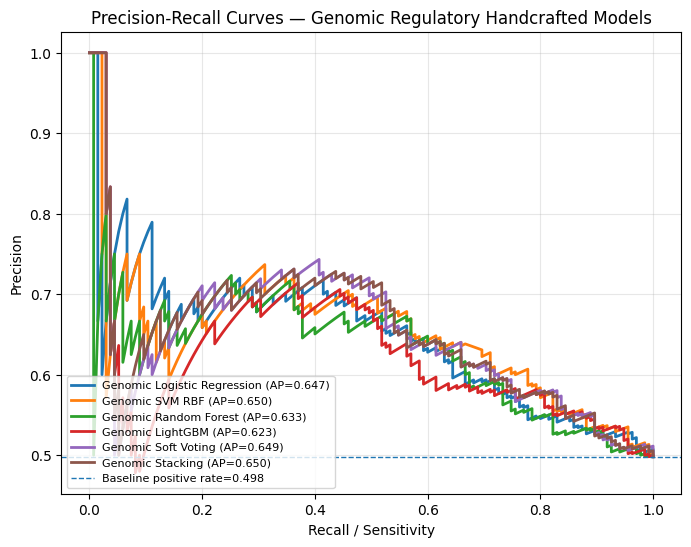

,branch,model,feature_set,pr_auc
1,Genomic regulatory,SVM RBF,K3 + K4 + Basic,0.650405
5,Genomic regulatory,Stacking,K3 + K4 + Basic,0.650205
4,Genomic regulatory,Soft Voting,K3 + K4 + Basic,0.648989
0,Genomic regulatory,Logistic Regression,K3 + K4 + Basic,0.647477
2,Genomic regulatory,Random Forest,K3 + K4 + Basic,0.632732
3,Genomic regulatory,LightGBM,K3 + K4 + Basic,0.623016


Saved: /content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/figures/phase2_2_pr_curves_genomic_models.png


In [11]:
# ============================================================
# PR CURVES — GENOMIC MODELS
# ============================================================

plt.figure(figsize=(8, 6))

pr_rows = []

for model_name, score in test_scores.items():
    precision, recall, _ = precision_recall_curve(y_test, score)
    pr_auc = average_precision_score(y_test, score)

    plt.plot(recall, precision, linewidth=2, label=f"Genomic {model_name} (AP={pr_auc:.3f})")

    pr_rows.append({
        "branch": "Genomic regulatory",
        "model": model_name,
        "feature_set": MAIN_FEATURE_SET_NAME,
        "pr_auc": pr_auc
    })

positive_rate = np.mean(y_test)
plt.axhline(y=positive_rate, linestyle="--", linewidth=1, label=f"Baseline positive rate={positive_rate:.3f}")

plt.xlabel("Recall / Sensitivity")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — Genomic Regulatory Handcrafted Models")
plt.legend(loc="lower left", fontsize=8)
plt.grid(True, alpha=0.3)

pr_fig_path = PHASE2_FIGURE_DIR / "phase2_2_pr_curves_genomic_models.png"
plt.savefig(pr_fig_path, dpi=300, bbox_inches="tight")
plt.show()

genomic_pr_summary_df = pd.DataFrame(pr_rows).sort_values(
    by="pr_auc",
    ascending=False
)

display(genomic_pr_summary_df)

genomic_pr_summary_df.to_csv(
    PHASE2_RESULT_DIR / "phase2_2_genomic_pr_summary.csv",
    index=False
)

print("Saved:", pr_fig_path)

In [12]:
# ============================================================
# COMBINED PROTEIN VS GENOMIC SUMMARY
# ============================================================

combined_rows = [
    {
        "branch": "Protein",
        "representation": "ProtBERT sliding-window",
        "model": "Logistic Regression",
        "threshold_policy": "default_0.5",
        "test_roc_auc": 0.6487,
        "test_pr_auc": 0.6551,
        "test_f1": 0.5896,
        "test_mcc": 0.1941,
        "note": "Best protein ranking representation"
    },
    {
        "branch": "Protein",
        "representation": "ProtBERT sliding-window",
        "model": "Logistic Regression",
        "threshold_policy": "validation_tuned_f1",
        "test_roc_auc": 0.6487,
        "test_pr_auc": 0.6551,
        "test_f1": 0.6906,
        "test_mcc": 0.2409,
        "note": "Best practical protein binary result after threshold tuning"
    },
    {
        "branch": "Genomic regulatory",
        "representation": MAIN_FEATURE_SET_NAME,
        "model": "Random Forest",
        "threshold_policy": "default_0.5",
        "test_roc_auc": default_genomic_threshold_df.loc[
            default_genomic_threshold_df["model"] == "Random Forest", "test_roc_auc"
        ].iloc[0],
        "test_pr_auc": default_genomic_threshold_df.loc[
            default_genomic_threshold_df["model"] == "Random Forest", "test_pr_auc"
        ].iloc[0],
        "test_f1": default_genomic_threshold_df.loc[
            default_genomic_threshold_df["model"] == "Random Forest", "test_f1"
        ].iloc[0],
        "test_mcc": default_genomic_threshold_df.loc[
            default_genomic_threshold_df["model"] == "Random Forest", "test_mcc"
        ].iloc[0],
        "note": "Official final genomic model selected by validation ROC-AUC"
    },
    {
        "branch": "Genomic regulatory",
        "representation": MAIN_FEATURE_SET_NAME,
        "model": "SVM RBF",
        "threshold_policy": "diagnostic_default_0.5",
        "test_roc_auc": default_genomic_threshold_df.loc[
            default_genomic_threshold_df["model"] == "SVM RBF", "test_roc_auc"
        ].iloc[0],
        "test_pr_auc": default_genomic_threshold_df.loc[
            default_genomic_threshold_df["model"] == "SVM RBF", "test_pr_auc"
        ].iloc[0],
        "test_f1": default_genomic_threshold_df.loc[
            default_genomic_threshold_df["model"] == "SVM RBF", "test_f1"
        ].iloc[0],
        "test_mcc": default_genomic_threshold_df.loc[
            default_genomic_threshold_df["model"] == "SVM RBF", "test_mcc"
        ].iloc[0],
        "note": "Diagnostic best genomic model on held-out test; not official final selection"
    }
]

# Add official RF tuned threshold row
combined_rows.append({
    "branch": "Genomic regulatory",
    "representation": MAIN_FEATURE_SET_NAME,
    "model": "Random Forest",
    "threshold_policy": "validation_tuned_mcc",
    "test_roc_auc": official_rf_mcc_row["test_roc_auc"],
    "test_pr_auc": official_rf_mcc_row["test_pr_auc"],
    "test_f1": official_rf_mcc_row["test_f1"],
    "test_mcc": official_rf_mcc_row["test_mcc"],
    "note": "Official genomic model with validation-tuned MCC threshold"
})

protein_vs_genomic_final_df = pd.DataFrame(combined_rows)

display(
    protein_vs_genomic_final_df.sort_values(
        by=["test_roc_auc", "test_mcc"],
        ascending=False
    )
)

protein_vs_genomic_final_df.to_csv(
    PHASE2_RESULT_DIR / "phase2_2_final_protein_vs_genomic_comparison.csv",
    index=False
)

,branch,representation,model,threshold_policy,test_roc_auc,test_pr_auc,test_f1,test_mcc,note
3,Genomic regulatory,K3 + K4 + Basic,SVM RBF,diagnostic_default_0.5,0.676471,0.650405,0.661972,0.293342,Diagnostic best genomic model on held-out test; not official final selection
2,Genomic regulatory,K3 + K4 + Basic,Random Forest,default_0.5,0.649619,0.632732,0.640569,0.255669,Official final genomic model selected by validation ROC-AUC
4,Genomic regulatory,K3 + K4 + Basic,Random Forest,validation_tuned_mcc,0.649619,0.632732,0.406250,0.192046,Official genomic model with validation-tuned MCC threshold
1,Protein,ProtBERT sliding-window,Logistic Regression,validation_tuned_f1,0.648700,0.655100,0.690600,0.240900,Best practical protein binary result after threshold tuning
0,Protein,ProtBERT sliding-window,Logistic Regression,default_0.5,0.648700,0.655100,0.589600,0.194100,Best protein ranking representation


In [13]:
# ============================================================
# ERROR ANALYSIS — OFFICIAL RANDOM FOREST
# ============================================================

official_rf_model = genomic_models["Random Forest"]
official_rf_score = test_scores["Random Forest"]

official_rf_pred_df = build_prediction_table(
    meta_df=test_df,
    y_true=y_test,
    y_score=official_rf_score,
    threshold=official_rf_threshold,
    model_name="Random Forest",
    feature_set=MAIN_FEATURE_SET_NAME
)

display(official_rf_pred_df.head())

official_rf_pred_df.to_csv(
    PHASE2_RESULT_DIR / "phase2_2_error_analysis_random_forest_test_predictions.csv",
    index=False
)

,gene_id,gene_symbol,gene_name,label,dataset_role,ensembl_gene_id,ensembl_gene_name,gene_type,chromosome_or_scaffold,gene_start_bp,gene_end_bp,strand,tss_sequence_orientation,regulatory_sequence_source,regulatory_sequence_scope,regulatory_sequence_version,regulatory_sequence,regulatory_sequence_length,n_N_bases,invalid_dna_chars,true_label,pred_score_t2d_associated,pred_label,threshold,model,feature_set,error_type
0,ENSG00000101639,CEP192,centrosomal protein 192,1,positive,ENSG00000101639,CEP192,protein_coding,18,12991315.0,13125053.0,1.0,forward_gene_orientation,Ensembl Homo sapiens GRCh38 primary assembly FASTA,TSS-proximal window: 2000 bp upstream + 500 bp downstream,TSS_Proximal_2kbUp_500bpDown_NuclearBalanced_v1,GTATAAGATAATAGCTAATGTTTGTTGAGTATTTCCATGGGCCATTATTTTTCTAGATACCTTACAGAAGTAGCTTTAAATCCTCACAGTAAGCCTCTGAGGCAAGCGCTTTAATTATCCCCACTTTACAGACAAGGAAACCGGCT...,2500,0,NaN,1,0.452821,0,0.6,Random Forest,K3 + K4 + Basic,FN
1,ENSG00000198793,MTOR,mechanistic target of rapamycin kinase,1,positive,ENSG00000198793,MTOR,protein_coding,1,11106531.0,11262556.0,-1.0,reverse_complement_gene_orientation,Ensembl Homo sapiens GRCh38 primary assembly FASTA,TSS-proximal window: 2000 bp upstream + 500 bp downstream,TSS_Proximal_2kbUp_500bpDown_NuclearBalanced_v1,TATTATACTTACATTGTTGCACAACTTGTAATTTTTAAACTAGTTGTGAACCTTTTCCTTCTTAGCAAATATTCATCTAATTACCACTATTTATTGTTATTATTATTATTTGAGACAGGATCTTTCTCTGCTGCCCAGGCTGCAGT...,2500,0,NaN,1,0.386692,0,0.6,Random Forest,K3 + K4 + Basic,FN
2,ENSG00000064607,SUGP2,SUGP2,0,negative,ENSG00000064607,SUGP2,protein_coding,19,18990888.0,19034040.0,-1.0,reverse_complement_gene_orientation,Ensembl Homo sapiens GRCh38 primary assembly FASTA,TSS-proximal window: 2000 bp upstream + 500 bp downstream,TSS_Proximal_2kbUp_500bpDown_NuclearBalanced_v1,AGTACAGATTTGGAACACATAAGATGGTGCCTGGAGATGGCCAAGTAAGAATTACCTGGAGAACAGCCTAGGCTAAAAGGGGGAAGCAGCATTACCAGTCCCTATTATCCATCAGGGCATGCTGAGGGTAAAACAGAAGATGAGTA...,2500,0,NaN,0,0.490883,0,0.6,Random Forest,K3 + K4 + Basic,TN
3,ENSG00000180332,KCTD4,KCTD4,0,negative,ENSG00000180332,KCTD4,protein_coding,13,45192853.0,45201045.0,-1.0,reverse_complement_gene_orientation,Ensembl Homo sapiens GRCh38 primary assembly FASTA,TSS-proximal window: 2000 bp upstream + 500 bp downstream,TSS_Proximal_2kbUp_500bpDown_NuclearBalanced_v1,AGTATCCTATATTCAAAGCAAAGGCCTTGTCTTACATATACATCAGCAACTAAATGTACATTTATTTTATTTTATTTTATTTCTGAGATGATGTCTCACTCTGTCACCCAGGCTGGAGTAGCTGGAGTACAGTGGTGCAATCTCAA...,2500,0,NaN,0,0.460903,0,0.6,Random Forest,K3 + K4 + Basic,TN
4,ENSG00000166226,CCT2,CCT2,0,negative,ENSG00000166226,CCT2,protein_coding,12,69585423.0,69601577.0,1.0,forward_gene_orientation,Ensembl Homo sapiens GRCh38 primary assembly FASTA,TSS-proximal window: 2000 bp upstream + 500 bp downstream,TSS_Proximal_2kbUp_500bpDown_NuclearBalanced_v1,CATTGGTTTCCCCATCACACACAGTCTCAGGCTTGCCTACCAGAGGACATAATAAATATCTCCAGGTATGTAATTTTGCCCACAATAAAAACAACCTTTTTCAATATTGTGCAGGCATCTTAGTTTTTTATTGTGAATCTTCTCAT...,2500,0,NaN,0,0.392621,0,0.6,Random Forest,K3 + K4 + Basic,TN


In [14]:
# ============================================================
# ERROR TYPE SUMMARY
# ============================================================

def summarize_error_types(pred_df, model_name):
    counts = pred_df["error_type"].value_counts().to_dict()

    tp = counts.get("TP", 0)
    tn = counts.get("TN", 0)
    fp = counts.get("FP", 0)
    fn = counts.get("FN", 0)

    return {
        "model": model_name,
        "threshold": pred_df["threshold"].iloc[0],
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "n": len(pred_df),
        "fp_rate_among_actual_negative": fp / max(fp + tn, 1),
        "fn_rate_among_actual_positive": fn / max(fn + tp, 1),
        "accuracy": accuracy_score(pred_df["true_label"], pred_df["pred_label"]),
        "f1": f1_score(pred_df["true_label"], pred_df["pred_label"], zero_division=0),
        "mcc": matthews_corrcoef(pred_df["true_label"], pred_df["pred_label"]),
    }

official_rf_error_summary_df = pd.DataFrame([
    summarize_error_types(official_rf_pred_df, "Random Forest")
])

display(official_rf_error_summary_df)

official_rf_error_summary_df.to_csv(
    PHASE2_RESULT_DIR / "phase2_2_error_summary_random_forest.csv",
    index=False
)

,model,threshold,TP,TN,FP,FN,n,fp_rate_among_actual_negative,fn_rate_among_actual_positive,accuracy,f1,mcc
0,Random Forest,0.6,39,118,18,96,271,0.132353,0.711111,0.579336,0.40625,0.192046


In [15]:
# ============================================================
# HIGH-CONFIDENCE FALSE POSITIVES / FALSE NEGATIVES
# ============================================================

def get_high_confidence_errors(pred_df, top_n=30):
    fp_high = pred_df[pred_df["error_type"] == "FP"].sort_values(
        by="pred_score_t2d_associated",
        ascending=False
    ).head(top_n)

    fn_high = pred_df[pred_df["error_type"] == "FN"].sort_values(
        by="pred_score_t2d_associated",
        ascending=True
    ).head(top_n)

    return fp_high, fn_high


rf_fp_high, rf_fn_high = get_high_confidence_errors(
    official_rf_pred_df,
    top_n=30
)

print("High-confidence false positives:")
display(rf_fp_high[[
    "gene_id",
    "gene_symbol",
    "label",
    "dataset_role",
    "true_label",
    "pred_label",
    "pred_score_t2d_associated",
    "error_type"
]].head(30))

print("High-confidence false negatives:")
display(rf_fn_high[[
    "gene_id",
    "gene_symbol",
    "label",
    "dataset_role",
    "true_label",
    "pred_label",
    "pred_score_t2d_associated",
    "error_type"
]].head(30))

rf_fp_high.to_csv(
    PHASE2_RESULT_DIR / "phase2_2_high_confidence_false_positives_random_forest.csv",
    index=False
)

rf_fn_high.to_csv(
    PHASE2_RESULT_DIR / "phase2_2_high_confidence_false_negatives_random_forest.csv",
    index=False
)

High-confidence false positives:


,gene_id,gene_symbol,label,dataset_role,true_label,pred_label,pred_score_t2d_associated,error_type
249,ENSG00000148143,ZNF462,0,negative,0,1,0.722197,FP
159,ENSG00000185774,KCNIP4,0,negative,0,1,0.707351,FP
214,ENSG00000086475,SEPHS1,0,negative,0,1,0.688862,FP
251,ENSG00000069188,SDK2,0,negative,0,1,0.675139,FP
17,ENSG00000157212,PAXIP1,0,negative,0,1,0.674440,FP
133,ENSG00000169594,BNC1,0,negative,0,1,0.665248,FP
268,ENSG00000049192,ADAMTS6,0,negative,0,1,0.662667,FP
182,ENSG00000075461,CACNG4,0,negative,0,1,0.660352,FP
156,ENSG00000166450,PRTG,0,negative,0,1,0.647760,FP
35,ENSG00000160072,ATAD3B,0,negative,0,1,0.645084,FP


High-confidence false negatives:


,gene_id,gene_symbol,label,dataset_role,true_label,pred_label,pred_score_t2d_associated,error_type
232,ENSG00000030110,BAK1,1,positive,1,0,0.313347,FN
24,ENSG00000168653,NDUFS5,1,positive,1,0,0.324342,FN
128,ENSG00000106328,FSCN3,1,positive,1,0,0.341953,FN
137,ENSG00000184381,PLA2G6,1,positive,1,0,0.354548,FN
213,ENSG00000165006,UBAP1,1,positive,1,0,0.364106,FN
259,ENSG00000144218,AFF3,1,positive,1,0,0.368254,FN
201,ENSG00000198056,PRIM1,1,positive,1,0,0.373418,FN
241,ENSG00000186510,CLCNKA,1,positive,1,0,0.376773,FN
67,ENSG00000124783,SSR1,1,positive,1,0,0.380367,FN
87,ENSG00000131781,FMO5,1,positive,1,0,0.381281,FN


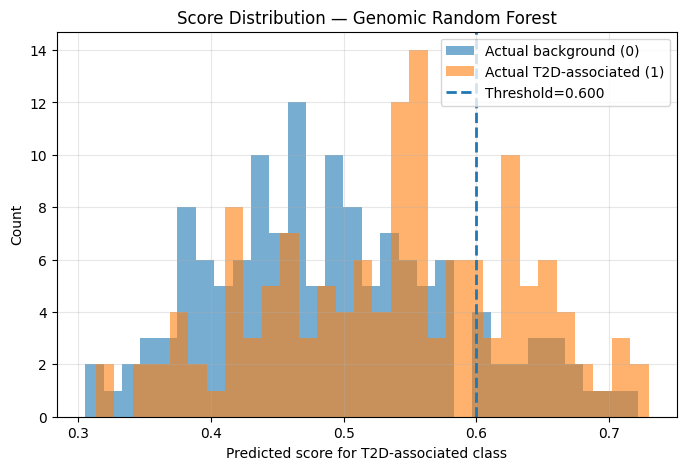

Saved: /content/drive/MyDrive/Project_Protein/model/phase2_2_genomic_analysis/figures/phase2_2_score_distribution_random_forest.png


In [16]:
# ============================================================
# SCORE DISTRIBUTION BY TRUE CLASS
# ============================================================

def plot_score_distribution(pred_df, title, output_path):
    plt.figure(figsize=(8, 5))

    score_col = "pred_score_t2d_associated"

    scores_0 = pred_df[pred_df["true_label"] == 0][score_col]
    scores_1 = pred_df[pred_df["true_label"] == 1][score_col]

    plt.hist(scores_0, bins=30, alpha=0.6, label="Actual background (0)")
    plt.hist(scores_1, bins=30, alpha=0.6, label="Actual T2D-associated (1)")

    threshold = pred_df["threshold"].iloc[0]
    plt.axvline(threshold, linestyle="--", linewidth=2, label=f"Threshold={threshold:.3f}")

    plt.xlabel("Predicted score for T2D-associated class")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()


score_dist_path = PHASE2_FIGURE_DIR / "phase2_2_score_distribution_random_forest.png"

plot_score_distribution(
    official_rf_pred_df,
    title="Score Distribution — Genomic Random Forest",
    output_path=score_dist_path
)

print("Saved:", score_dist_path)

In [17]:
# ============================================================
# RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_pipeline = genomic_models["Random Forest"]

# Pipeline steps: variance -> model
rf_model = rf_pipeline.named_steps["model"]

# Need feature names after VarianceThreshold
if "variance" in rf_pipeline.named_steps:
    variance_selector = rf_pipeline.named_steps["variance"]
    selected_mask = variance_selector.get_support()
    selected_features = X_train.columns[selected_mask]
else:
    selected_features = X_train.columns

rf_importance_df = pd.DataFrame({
    "feature": selected_features,
    "importance": rf_model.feature_importances_
}).sort_values(
    by="importance",
    ascending=False
)

display(rf_importance_df.head(50))

rf_importance_df.to_csv(
    PHASE2_RESULT_DIR / "phase2_2_random_forest_feature_importance.csv",
    index=False
)

,feature,importance
325,k4_TGAG,0.015787
109,k4_AAGG,0.012512
184,k4_CCCC,0.011546
26,GC_content_bin_08,0.011130
222,k4_CTGT,0.009443
202,k4_CGCT,0.007480
85,k3_TAG,0.007211
240,k4_GATC,0.006885
145,k4_AGTG,0.006837
226,k4_CTTT,0.006661


In [18]:
# ============================================================
# LOGISTIC REGRESSION COEFFICIENTS
# Useful because LR is more interpretable/stable.
# ============================================================

if "Logistic Regression" in genomic_models:
    lr_pipeline = genomic_models["Logistic Regression"]

    lr_model = lr_pipeline.named_steps["model"]

    if "variance" in lr_pipeline.named_steps:
        lr_variance_selector = lr_pipeline.named_steps["variance"]
        lr_selected_mask = lr_variance_selector.get_support()
        lr_selected_features = X_train.columns[lr_selected_mask]
    else:
        lr_selected_features = X_train.columns

    lr_coef_df = pd.DataFrame({
        "feature": lr_selected_features,
        "coefficient": lr_model.coef_[0]
    })

    lr_coef_df["abs_coefficient"] = lr_coef_df["coefficient"].abs()

    lr_coef_df = lr_coef_df.sort_values(
        by="abs_coefficient",
        ascending=False
    )

    display(lr_coef_df.head(50))

    lr_coef_df.to_csv(
        PHASE2_RESULT_DIR / "phase2_2_logistic_regression_coefficients.csv",
        index=False
    )

,feature,coefficient,abs_coefficient
222,k4_CTGT,-0.038602,0.038602
190,k4_CCGT,-0.034940,0.034940
152,k4_ATCC,-0.034604,0.034604
109,k4_AAGG,0.033558,0.033558
240,k4_GATC,-0.030320,0.030320
277,k4_GTAG,-0.030079,0.030079
101,k4_AAAG,0.029627,0.029627
325,k4_TGAG,-0.029322,0.029322
104,k4_AACC,-0.028587,0.028587
321,k4_TCTG,-0.027517,0.027517


In [19]:
# ============================================================
# WRITE PHASE 2.2 SUMMARY REPORT
# ============================================================

best_default_row = default_genomic_threshold_df.sort_values(
    by=["test_roc_auc", "test_mcc"],
    ascending=False
).iloc[0]

best_tuned_row = genomic_threshold_tuning_df.sort_values(
    by=["test_mcc", "test_f1", "test_roc_auc"],
    ascending=False
).iloc[0]

summary_text = f"""
# Phase 2.2 — Genomic Threshold Tuning, ROC/PR Curves, and Error Analysis

## Objective

Phase 2.2 evaluated the genomic regulatory handcrafted baseline beyond default-threshold testing.
The goals were to tune decision thresholds, compare ROC/PR ranking performance, and analyze errors for the genomic regulatory branch.

## Feature Representation

The selected genomic feature set was:

{MAIN_FEATURE_SET_NAME}

This feature set includes:
- Basic DNA composition
- GC and AT content
- CpG features
- GC/AT skew
- Positional GC bins
- 3-mer frequencies
- 4-mer frequencies

## Default Threshold Results

The official final genomic model selected in Phase 2.1 was Random Forest based on validation ROC-AUC.

At threshold 0.5, Random Forest achieved:

- Test ROC-AUC: {default_genomic_threshold_df.loc[default_genomic_threshold_df['model'] == 'Random Forest', 'test_roc_auc'].iloc[0]:.4f}
- Test PR-AUC: {default_genomic_threshold_df.loc[default_genomic_threshold_df['model'] == 'Random Forest', 'test_pr_auc'].iloc[0]:.4f}
- Test F1: {default_genomic_threshold_df.loc[default_genomic_threshold_df['model'] == 'Random Forest', 'test_f1'].iloc[0]:.4f}
- Test MCC: {default_genomic_threshold_df.loc[default_genomic_threshold_df['model'] == 'Random Forest', 'test_mcc'].iloc[0]:.4f}

Diagnostic testing showed that the best test ROC-AUC model at default threshold was:

- Model: {best_default_row['model']}
- Test ROC-AUC: {best_default_row['test_roc_auc']:.4f}
- Test PR-AUC: {best_default_row['test_pr_auc']:.4f}
- Test F1: {best_default_row['test_f1']:.4f}
- Test MCC: {best_default_row['test_mcc']:.4f}

This diagnostic result was not used to change the official final model, because model selection was based on validation performance.

## Threshold Tuning

Threshold tuning was performed using the validation set for:
- Random Forest
- SVM RBF
- Logistic Regression

The best tuned test result by MCC was:

- Model: {best_tuned_row['model']}
- Tuned for: {best_tuned_row['tuned_for']}
- Threshold: {best_tuned_row['best_threshold']:.3f}
- Test ROC-AUC: {best_tuned_row['test_roc_auc']:.4f}
- Test PR-AUC: {best_tuned_row['test_pr_auc']:.4f}
- Test F1: {best_tuned_row['test_f1']:.4f}
- Test MCC: {best_tuned_row['test_mcc']:.4f}

## Official Genomic Model Error Analysis

The official Random Forest model with validation-tuned MCC threshold achieved:

- Threshold: {official_rf_threshold:.3f}
- TP: {int(official_rf_error_summary_df['TP'].iloc[0])}
- TN: {int(official_rf_error_summary_df['TN'].iloc[0])}
- FP: {int(official_rf_error_summary_df['FP'].iloc[0])}
- FN: {int(official_rf_error_summary_df['FN'].iloc[0])}
- F1: {official_rf_error_summary_df['f1'].iloc[0]:.4f}
- MCC: {official_rf_error_summary_df['mcc'].iloc[0]:.4f}

## Interpretation

The genomic regulatory handcrafted branch produced performance comparable to the protein ProtBERT branch.
This suggests that TSS-proximal regulatory DNA sequences contain meaningful signal for distinguishing T2D-associated genes from strict background genes.

The genomic branch was particularly strong in threshold-based metrics such as F1 and MCC, while the protein branch retained stronger PR-AUC in the best protein setting.
This supports the hypothesis that protein and regulatory DNA representations capture complementary biological signals.

## Next Step

The next recommended step is to compare protein and genomic prediction errors and then prepare for multimodal integration:

Protein embedding + genomic regulatory features

Before integration, the following should be saved:
- Genomic prediction scores
- Protein prediction scores
- Shared gene_id mapping
- Error type tables for both modalities
"""

summary_path = PHASE2_REPORT_DIR / "phase2_2_genomic_threshold_curves_error_summary.md"

with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", summary_path)


# Phase 2.2 — Genomic Threshold Tuning, ROC/PR Curves, and Error Analysis

## Objective

Phase 2.2 evaluated the genomic regulatory handcrafted baseline beyond default-threshold testing.
The goals were to tune decision thresholds, compare ROC/PR ranking performance, and analyze errors for the genomic regulatory branch.

## Feature Representation

The selected genomic feature set was:

K3 + K4 + Basic

This feature set includes:
- Basic DNA composition
- GC and AT content
- CpG features
- GC/AT skew
- Positional GC bins
- 3-mer frequencies
- 4-mer frequencies

## Default Threshold Results

The official final genomic model selected in Phase 2.1 was Random Forest based on validation ROC-AUC.

At threshold 0.5, Random Forest achieved:

- Test ROC-AUC: 0.6496
- Test PR-AUC: 0.6327
- Test F1: 0.6406
- Test MCC: 0.2557

Diagnostic testing showed that the best test ROC-AUC model at default threshold was:

- Model: SVM RBF
- Test ROC-AUC: 0.6765
- Test PR-AUC: 0.6504
- Test F1: 0.6620
- Test M